# Métricas de avaliação de modelos de classificação

Vamos falar sobre as métricas de avaliação de modelos de classificação. Esse material serve de apoio aos nossos notebooks de classificação com a base *breast cancer*.

Vou usar exemplos auxiliares do livro *Grokking Machine Learning* de Luis Serrano, editora Manning, 2021

## Bases de dados de exemplo

Dataset médico - pacientes com COVID-19

- 1000 pacientes
- 990 saudáveis
- 10 com COVID-19


Dataset de emails - spam e não spam

- 100 emails
- 40 spam
- 60 não spam

## Problemas da acurácia

A acurácia é dada por:

$$
\text{acurácia} = \frac{\text{número de predições corretas}}{\text{número total de predições}} 
$$

Modelo 1 - dataset médico - prevê que todos os pacientes estão saudáveis

- Acurácia: 990/1000 = 99%

O problema do modelo é que ele não considera que os erros têm pesos diferentes. Nesse caso, o erro de prever um paciente com COVID-19 como saudável é muito mais grave do que prever um paciente saudável como doente.

## Falsos positivos e falsos negativos

Considerando o dataset médico, um dado modelo pode ter classificado os pacientes da seguinte forma (considerando "positivo" como "doente"):

- Verdadeiro positivo (TP): prever um paciente com COVID-19 como doente
- Falso positivo (FP): prever um paciente saudável como doente
- Verdadeiro negativo (TN): prever um paciente saudável como saudável
- Falso negativo (FN): prever um paciente com COVID-19 como saudável

Assim, de forma geral, um falso positivo é um erro do modelo em prever um positivo quando o valor real é negativo. Um falso negativo é um erro do modelo em prever um negativo quando o valor real é positivo.

Considerando o dataset de emails, um modelo pode ter classificado os emails da seguinte forma (considerando "positivo" como "spam"):

- Verdadeiro positivo (TP): prever um email spam como spam
- Falso positivo (FP): prever um email não spam como spam
- Verdadeiro negativo (TN): prever um email não spam como não spam
- Falso negativo (FN): prever um email spam como não spam

Considere a figura abaixo, que ilustra esses conceitos para modelos de classificação binária considerando as bases de dados médica e de emails.

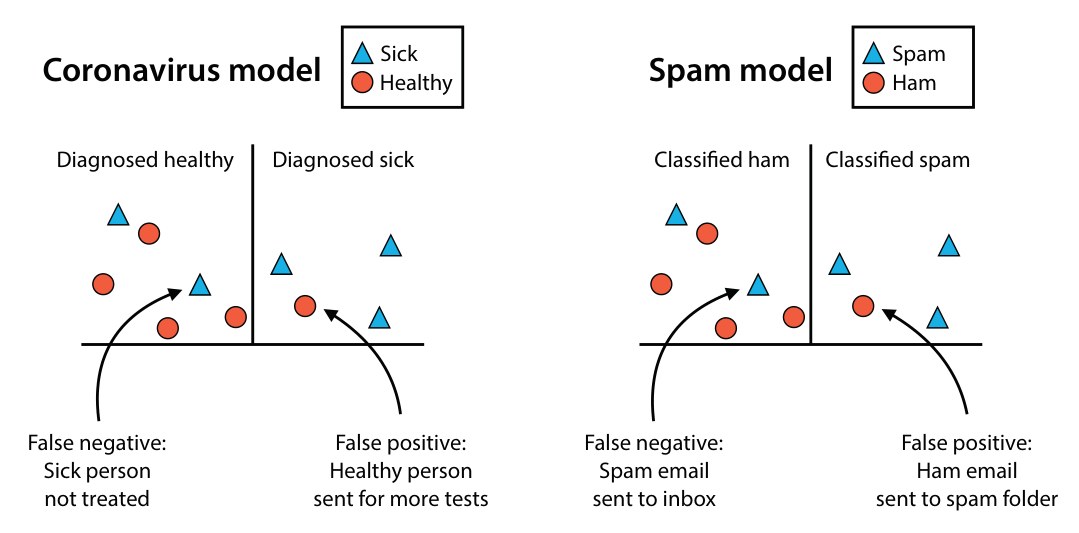

Note na imagem que, para ambas as bases, temos:

- 3 verdadeiros positivos
- 4 verdadeiros negativos
- 1 falso positivo
- 2 falsos negativos

Logo, a acurácia de ambos os modelos da figura é 7/10 = 70%. No entanto, a acurácia não considera a gravidade dos erros.

### Falsos positivos e falsos negativos na base médica

Pare e pense: qual é o erro mais grave na base médica? Um falso positivo ou um falso negativo?

Em outras palavras, qual é o erro mais grave: prever um paciente saudável como doente ou prever um paciente com COVID-19 como saudável?

Se diagnosticamos um paciente como saudável quando ele tem COVID-19, ele pode não receber o tratamento adequado e isso pode levar a problemas. Por outro lado, se diagnosticamos um paciente saudável como doente, ele vai passar por exames adicionais o que pode ser inconveniente (tempo, custo, etc), mas não traz riscos à saúde.

Assim, na base médica, um falso negativo é mais grave do que um falso positivo.

### Falsos positivos e falsos negativos na base de emails

Pare e pense: qual é o erro mais grave na base de emails? Um falso positivo ou um falso negativo?

Em outras palavras, qual é o erro mais grave: prever um email não spam como spam ou prever um email spam como não spam?

Se um email spam é classificado como não spam, ele pode chegar à caixa de entrada do usuário e isso pode ser inconveniente. Por outro lado, se um email não spam é classificado como spam, ele vai para a caixa de spam, o que pode fazer com que o usuário perca informações importantes.

Assim, na base de emails, um falso positivo é mais grave do que um falso negativo.

## Matriz de confusão

Um jeito de visualizar os resultados de um modelo de classificação é por meio da matriz de confusão. A matriz de confusão é uma tabela que mostra a frequência com que o modelo acertou e errou em suas previsões. A matriz de confusão para um modelo de classificação binária é composta por quatro células:

$$
\begin{array}{|c|c|c|}
\hline
& \text{predição negativa} & \text{predição positiva} \\
\hline
\text{classe negativa} & TN & FP \\
\hline
\text{classe positiva} & FN & TP \\
\hline
\end{array}
$$


Para problemas com mais de duas classes, a matriz de confusão é uma matriz quadrada de dimensão igual ao número de classes. Cada linha da matriz representa a classe real e cada coluna representa a classe prevista.

### Base médica - matriz de confusão

Vamos recordar o nosso primeiro modelo para a base médica, que previu que todos os pacientes estavam saudáveis:

- Verdadeiros positivos (TP): 0
- Falsos positivos (FP): 0
- Verdadeiros negativos (TN): 990
- Falsos negativos (FN): 10

A matriz de confusão para esse modelo é:

$$
\begin{array}{|c|c|c|}
\hline
& \text{Diagnosticado saudável} & \text{Diagnosticado doente} \\
\hline
\text{Saudável} & 990 & 0 \\
\hline
\text{Doente} & 10 & 0 \\
\hline
\end{array}
$$

Para exemplo, vamos considerar um segundo modelo para a base médica que tem a seguinte matriz de confusão:

$$
\begin{array}{|c|c|c|}
\hline
& \text{Diagnosticado saudável} & \text{Diagnosticado doente} \\
\hline
\text{Saudável} & 942 & 48 \\
\hline
\text{Doente} & 2 & 8 \\
\hline
\end{array}
$$

Esse modelo tem:

- Verdadeiros positivos (TP): 8
- Falsos positivos (FP): 48
- Verdadeiros negativos (TN): 942
- Falsos negativos (FN): 2

A acurácia, como visto anteriormente, é dada por:

$$
\text{acurácia} = \frac{\text{número de predições corretas}}{\text{número total de predições}} 
$$

A fórmula pode ser reescrita como:

$$
\text{acurácia} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Assim, para o primeiro modelo:

$$
\text{acurácia} = \frac{0 + 990}{0 + 990 + 0 + 10} = \frac{990}{1000} = 99\%
$$

E para o segundo modelo:

$$
\text{acurácia} = \frac{8 + 942}{8 + 942 + 48 + 2} = \frac{950}{1000} = 95\%
$$


Considerando a acurácia, o primeiro modelo é melhor que o segundo. No entanto, como vimos anteriormente, a acurácia não considera a gravidade dos erros. O primeiro modelo teve 10 falsos negativos (pacientes com COVID-19 diagnosticados como saudáveis), enquanto o segundo teve apenas 2 falsos negativos, embora tenha tido 48 falsos positivos (pacientes saudáveis diagnosticados como doentes). Assim, o segundo modelo pode ser considerado melhor que o primeiro, dentro do contexto da base médica.

### Base de emails - matriz de confusão

Considerando a base de emails, vamos considerar um modelo que tem a seguinte matriz de confusão:

$$
\begin{array}{|c|c|c|}
\hline
& \text{Predito não spam} & \text{Predito spam} \\
\hline
\text{Não spam} & 55 & 5 \\
\hline
\text{Spam} & 10 & 30 \\
\hline
\end{array}
$$

Esse modelo tem:

- Verdadeiros positivos (TP): 30
- Falsos positivos (FP): 5
- Verdadeiros negativos (TN): 55
- Falsos negativos (FN): 10

A acurácia do modelo é:

$$
\text{acurácia} = \frac{30 + 55}{30 + 55 + 5 + 10} = \frac{85}{100} = 85\%
$$

Ainda com a base de emails, vamos considerar um segundo modelo que tem a seguinte matriz de confusão:

$$
\begin{array}{|c|c|c|}
\hline
& \text{Predito não spam} & \text{Predito spam} \\
\hline
\text{Não spam} & 50 & 10 \\
\hline
\text{Spam} & 5 & 35 \\
\hline
\end{array}
$$

Esse modelo tem:

- Verdadeiros positivos (TP): 35
- Falsos positivos (FP): 10
- Verdadeiros negativos (TN): 50
- Falsos negativos (FN): 5

A acurácia do modelo é:

$$
\text{acurácia} = \frac{35 + 50}{35 + 50 + 10 + 5} = \frac{85}{100} = 85\%
$$


Considerando a acurácia, os dois modelos são iguais. No entanto, o primeiro modelo teve 5 falsos positivos (emails não spam classificados como spam), enquanto o segundo teve 10 falsos positivos, embora tenha tido 5 falsos negativos (emails spam classificados como não spam). Assim, o primeiro modelo pode ser considerado melhor que o segundo, dentro do contexto da base de emails.

## Recall

Vimos anteriormente que, em alguns contextos, um falso positivo é mais grave que um falso negativo, enquanto em outros contextos, um falso negativo é mais grave que um falso positivo. Para lidar com essa questão, podemos usar métricas de avaliação que consideram a gravidade dos erros.

No caso da base médica, um falso negativo é mais grave que um falso positivo. Assim, uma métrica que considera a gravidade dos falsos negativos é o *recall*. O recall é dado por:

$$
\text{recall} = \frac{TP}{TP + FN}
$$

O recall é a proporção de positivos reais que foram corretamente identificados pelo modelo. Em outras palavras, o recall mede a capacidade do modelo de encontrar todos os positivos.

Vamos calcular o recall para os modelos da base médica:

- Modelo 1: recall = 0/(0 + 10) = 0
- Modelo 2: recall = 8/(8 + 2) = 0.8 = 80%

Observe que o recall do modelo 1 é 0, pois ele não identificou nenhum paciente com COVID-19. Já o recall do modelo 2 é 80%, pois ele identificou 8 dos 10 pacientes com COVID-19. Assim, esta métrica nos ajuda a entender que o modelo 2 é melhor que o modelo 1, dentro do contexto da base médica.

Já para os modelos da base de emails:

- Modelo 1: recall = 30/(30 + 10) = 0.75 = 75%
- Modelo 2: recall = 35/(35 + 5) = 0.875 = 87.5%

Observe que o recall do modelo 1 é 75%, pois ele identificou 30 dos 40 emails spam. Já o recall do modelo 2 é 87.5%, pois ele identificou 35 dos 40 emails spam. No entanto, dentro do contexto da base de emails, já conversamos que um falso positivo é mais grave que um falso negativo. Vejamos outra métrica que considera a gravidade dos falsos positivos.

## Precisão

No caso da base de emails, um falso positivo é mais grave que um falso negativo. Assim, uma métrica que considera a gravidade dos falsos positivos é a *precisão*. A precisão é dada por:

$$
\text{precisão} = \frac{TP}{TP + FP}
$$

A precisão é a proporção de positivos previstos pelo modelo que são realmente positivos. Em outras palavras, a precisão mede a capacidade do modelo de prever corretamente os positivos.

Valores altos de precisão indicam que o modelo tem poucos falsos positivos.

Vamos calcular a precisão para os modelos da base médica:

- Modelo 1: precisão = 0/(0 + 0) = indefinido (divisão por zero) - por convenção, consideramos a precisão como 1 (100%)
- Modelo 2: precisão = 8/(8 + 48) = 0.143 = 14.3%

Observe que a precisão do modelo 1 é indefinida, pois ele não previu nenhum paciente com COVID-19. Por convenção, consideramos a precisão como 1 (100%). Já a precisão do modelo 2 é 14.3%, pois ele previu corretamente 8 dos 56 pacientes doentes.

Vamos calcular a precisão para os modelos da base de emails:

- Modelo 1: precisão = 30/(30 + 5) = 0.857 = 85.7%
- Modelo 2: precisão = 35/(35 + 10) = 0.778 = 77.8%

Observe que a precisão do modelo 1 é 85.7%, pois ele previu corretamente 30 dos 35 emails spam. Já a precisão do modelo 2 é 77.8%, pois ele previu corretamente 35 dos 45 emails spam. Assim, a precisão nos ajuda a entender que o modelo 1 é melhor que o modelo 2, dentro do contexto da base de emails.

## F-Score

Tanto o recall quanto a precisão são métricas importantes para avaliar modelos de classificação. No entanto, em alguns casos, é interessante ter uma única métrica que combine essas duas informações. Isto porque, em alguns casos, é possível "enganar" o modelo para que ele tenha um recall alto, mas uma precisão baixa, ou vice-versa.

Por exemplo, um modelo que prevê que todos os pacientes estão doentes terá um recall de 100%, mas uma precisão de 0%. Ou, um modelo que prevê que todo e-mail não é spam terá uma precisão de 100%. Tenha em mente que toda métrica tem suas limitações e é importante considerar o contexto do problema.

Considerando a base médica, podemos querer um modelo que busque minimizar os falsos negativos (pacientes com COVID-19 diagnosticados como saudáveis) mas que também tenha uma precisão razoável, já que falsos positivos (pacientes saudáveis diagnosticados como doentes) podem gerar custos adicionais para o sistema de saúde e para os pacientes, dentre outros inconvenientes.


Uma métrica que combina recall e precisão é o *F-Score*. Ou mais corretamente, $F_{\beta}$-Score, que é uma média ponderada entre recall e precisão. O $F_{\beta}$-Score é dado por:

$$
F_{\beta}\text{-Score} = (1 + \beta^2) \cdot \frac{\text{precisão} \cdot \text{recall}}{\beta^2 \cdot \text{precisão} + \text{recall}}
$$

Observe que há um parâmetro $\beta$ que controla o peso entre precisão e recall. Quando $\beta = 1$, temos o $F_1$-Score, que é a média harmônica entre precisão e recall. 

Uma média harmônica é uma média que dá mais peso aos valores menores. Considerando dois números $a$ e $b$, a média harmônica é dada por:

$$
\text{média harmônica} = \frac{2}{\frac{1}{a} + \frac{1}{b}} = \frac{2ab}{a + b}
$$

A média harmônica se aproxima do menor valor entre $a$ e $b$. E sempre será menor ou igual à média aritmética entre $a$ e $b$.

Por exemplo, se os números forem iguais, a média harmônica será igual a eles. Se um número for muito menor que o outro, como 1 e 9, a média harmônica será próxima de 1, mais especificamente, 1.8.

O $F_1$-Score é dado por:

$$
F_1\text{-Score} = 2 \cdot \frac{\text{precisão} \cdot \text{recall}}{\text{precisão} + \text{recall}}
$$

O $F_1$-Score é uma métrica que combina precisão e recall de forma balanceada. 

In [1]:
def f_score(precisao, recall, beta=1):
    return (1 + beta**2) * (precisao * recall) / (beta**2 * precisao + recall)

In [2]:
recall_base_medica_modelo_1 = 0 #pior modelo, não detecta nenhum caso positivo
recall_base_medica_modelo_2 = 0.8 #melhor modelo, detecta 80% dos casos positivos

precisao_base_medica_modelo_1 = 1 #pior modelo, detecta apenas casos positivos, ou seja, tem 100% de precisão, mas não detecta nenhum caso positivo
precisao_base_medica_modelo_2 = 0.143 #melhor modelo, detecta 14.3% dos casos positivos, ou seja, tem 14.3% de precisão, mas detecta 80% dos casos positivos


Para nossos modelos da base médica:


In [3]:
f_score_medica_modelo_1 = f_score(precisao_base_medica_modelo_1, recall_base_medica_modelo_1)
f_score_medica_modelo_2 = f_score(precisao_base_medica_modelo_2, recall_base_medica_modelo_2)

print(f'F-Score modelo 1 base médica: {f_score_medica_modelo_1}') #pior modelo, F-Score é 0, pois o recall é 0
print(f'F-Score modelo 2 base médica: {f_score_medica_modelo_2}') #melhor modelo, F-Score é 0.24, pois o recall é 0.8 e a precisão é 0.143

F-Score modelo 1 base médica: 0.0
F-Score modelo 2 base médica: 0.24262990455991515


Para nossos modelos da base de emails:


In [4]:
recall_base_emails_modelo_1 = 0.75 #melhor modelo, detecta 75% dos casos positivos
recall_base_emails_modelo_2 = 0.875 #pior modelo, detecta 87.5% dos casos positivos, mas tem uma precisão muito baixa, ou seja, detecta muitos casos negativos como positivos

precisao_base_emails_modelo_1 = 0.857 #melhor modelo, tem 85.7% de precisão
precisao_base_emails_modelo_2 = 0.778 #pior modelo, tem 77.8% de precisão

In [5]:
f_score_emails_modelo_1 = f_score(precisao_base_emails_modelo_1, recall_base_emails_modelo_1)
f_score_emails_modelo_2 = f_score(precisao_base_emails_modelo_2, recall_base_emails_modelo_2)

print(f'F-Score modelo 1 base emails: {f_score_emails_modelo_1}') #melhor modelo, F-Score é 0.8, pois o recall é 0.75 e a precisão é 0.857
print(f'F-Score modelo 2 base emails: {f_score_emails_modelo_2}')  #pior modelo, F-Score é 0.82, pois o recall é 0.875 e a precisão é 0.778, ou seja, tem um recall melhor, mas uma precisão pior que o modelo 1, o que faz com que o F-Score seja melhor que o modelo 1

F-Score modelo 1 base emails: 0.7999377722464218
F-Score modelo 2 base emails: 0.8236539624924379


Com um beta de 0.5, o F-Score dá mais peso à precisão. Com um beta de 2, o F-Score dá mais peso ao recall. Vejamos os valores para os modelos da base médica e de emails:

In [6]:
# base médica com beta = 0.5
f_score_medica_modelo_1_beta_05 = f_score(precisao_base_medica_modelo_1, recall_base_medica_modelo_1, beta=0.5)
f_score_medica_modelo_2_beta_05 = f_score(precisao_base_medica_modelo_2, recall_base_medica_modelo_2, beta=0.5)

print(f'F-Score modelo 1 base médica beta 0.5: {f_score_medica_modelo_1_beta_05}') #pior modelo, F-Score é 0, pois o recall é 0, mesmo com beta = 0.5, o que mostra que o modelo é muito ruim, pois não detecta nenhum caso positivo, ou seja, tem um recall de 0, o que faz com que o F-Score seja 0, mesmo com uma precisão de 1
print(f'F-Score modelo 2 base médica beta 0.5: {f_score_medica_modelo_2_beta_05}') #melhor modelo, F-Score é 0.17, pois o recall é 0.8 e a precisão é 0.143 e com beta = 0.5, o que mostra que o modelo é ruim, pois tem uma precisão muito baixa, o que faz com que o F-Score seja baixo, mesmo com um recall de 0.8

F-Score modelo 1 base médica beta 0.5: 0.0
F-Score modelo 2 base médica beta 0.5: 0.17110379898294947


In [7]:
# base médica com beta = 2
f_score_medica_modelo_1_beta_2 = f_score(precisao_base_medica_modelo_1, recall_base_medica_modelo_1, beta=2)
f_score_medica_modelo_2_beta_2 = f_score(precisao_base_medica_modelo_2, recall_base_medica_modelo_2, beta=2)

print(f'F-Score modelo 1 base médica beta 2: {f_score_medica_modelo_1_beta_2}') #pior modelo, F-Score é 0, pois o recall é 0, mesmo com beta = 2, o que mostra que o modelo é muito ruim, pois não detecta nenhum caso positivo, ou seja, tem um recall de 0, o que faz com que o F-Score seja 0, mesmo com uma precisão de 1
print(f'F-Score modelo 2 base médica beta 2: {f_score_medica_modelo_2_beta_2}') #melhor modelo, F-Score é 0.41, pois o recall é 0.8 e a precisão é 0.143 e com beta = 2, o que mostra que o modelo é ruim, pois tem uma precisão muito baixa, o que faz com que o F-Score seja baixo, mesmo com um recall de 0.8, mas com beta = 2, o que dá mais peso ao recall, o que faz com que o F-Score seja melhor que com beta = 0.5, mas ainda assim é um modelo ruim, pois tem uma precisão muito baixa

F-Score modelo 1 base médica beta 2: 0.0
F-Score modelo 2 base médica beta 2: 0.4169096209912537


In [8]:
# base emails com beta = 0.5
f_score_emails_modelo_1_beta_05 = f_score(precisao_base_emails_modelo_1, recall_base_emails_modelo_1, beta=0.5)
f_score_emails_modelo_2_beta_05 = f_score(precisao_base_emails_modelo_2, recall_base_emails_modelo_2, beta=0.5)

print(f'F-Score modelo 1 base emails beta 0.5: {f_score_emails_modelo_1_beta_05}') #melhor modelo
print(f'F-Score modelo 2 base emails beta 0.5: {f_score_emails_modelo_2_beta_05}') #pior modelo

F-Score modelo 1 base emails beta 0.5: 0.8332253046409125
F-Score modelo 2 base emails beta 0.5: 0.7956404862085085


In [9]:
# base emails com beta = 2
f_score_emails_modelo_1_beta_2 = f_score(precisao_base_emails_modelo_1, recall_base_emails_modelo_1, beta=2)
f_score_emails_modelo_2_beta_2 = f_score(precisao_base_emails_modelo_2, recall_base_emails_modelo_2, beta=2)

print(f'F-Score modelo 1 base emails beta 2: {f_score_emails_modelo_1_beta_2}') #melhor modelo
print(f'F-Score modelo 2 base emails beta 2: {f_score_emails_modelo_2_beta_2}') #pior modelo

F-Score modelo 1 base emails beta 2: 0.7692077549066538
F-Score modelo 2 base emails beta 2: 0.8537120642086781


## ROC - Receiver Operating Characteristic

**ROC** é uma sigla para **Receiver Operating Characteristic**, que em português pode ser traduzido como **Característica de Operação do Receptor**. A origem desse termo remonta à **Segunda Guerra Mundial**, quando os engenheiros e analistas de sinais precisavam avaliar a eficácia dos sistemas de radar em detectar objetos inimigos.

- **Sistemas de Radar:** Durante a guerra, os operadores de radar enfrentavam o desafio de distinguir entre sinais reais (como aeronaves inimigas) e ruídos ou falsos alarmes causados por interferências.

- **Receptor (Receiver):** Refere-se ao equipamento que recebe os sinais de radar.

- **Característica de Operação (Operating Characteristic):** Relaciona-se ao desempenho do receptor em diferentes condições operacionais, especialmente na capacidade de equilibrar a detecção de verdadeiros alvos e a minimização de falsos alarmes.

Os analistas desenvolveram métodos para avaliar o desempenho dos receptores de radar, criando gráficos que mostravam a relação entre a **taxa de verdadeiros positivos** (detecções corretas) e a **taxa de falsos positivos** (falsos alarmes) em diferentes configurações.

Com o tempo, os conceitos utilizados na análise de sinais de radar foram adaptados para outras áreas, incluindo a estatística e a análise de classificadores em machine learning.





Uma curva ROC (Receiver Operating Characteristic) é uma representação gráfica da sensibilidade versus especificidade para um sistema classificador binário à medida que o limiar de discriminação é variado. A curva ROC é criada plotando a taxa de verdadeiros positivos (TPR) contra a taxa de falsos positivos (FPR) em vários valores de limiar.

A sensibilidade é a proporção de verdadeiros positivos (TP) que são corretamente identificados pelo modelo. A sensibilidade é dada por:

$$
\text{sensibilidade} = \frac{TP}{TP + FN}
$$

Como podemos ver, a sensibilidade é o mesmo que o recall.

A especificidade é a proporção de verdadeiros negativos (TN) que são corretamente identificados pelo modelo. A especificidade é dada por:

$$
\text{especificidade} = \frac{TN}{TN + FP}
$$

A taxa de falsos positivos (FPR) é a proporção de falsos positivos (FP) que são incorretamente identificados pelo modelo. A taxa de falsos positivos é dada por:

$$
\text{FPR} = \frac{FP}{FP + TN} = 1 - \text{especificidade}
$$

Como mencionado, sensibilidade é o mesmo que recall. No entanto, especificidade não é o mesmo que precisão (cada nomenclatura é popular em diferentes disciplinas, e por essa razão, usamos ambas aqui).

No modelo de coronavírus, a sensibilidade é a proporção de pessoas doentes que o modelo diagnosticou corretamente, entre todas as pessoas doentes. A especificidade é a proporção de pessoas saudáveis que o modelo diagnosticou corretamente, entre as pessoas saudáveis. Estamos mais preocupados em diagnosticar corretamente as pessoas doentes, por isso precisamos que o modelo de coronavírus tenha alta sensibilidade.  

No modelo de detecção de spam, a sensibilidade é a proporção de mensagens de spam que excluímos corretamente, entre todas as mensagens de spam. A especificidade é a proporção de e-mails ham que enviamos corretamente para a caixa de entrada, entre todos os e-mails ham. Como estamos mais preocupados em detectar corretamente os e-mails ham, precisamos que o modelo de detecção de spam tenha alta especificidade.

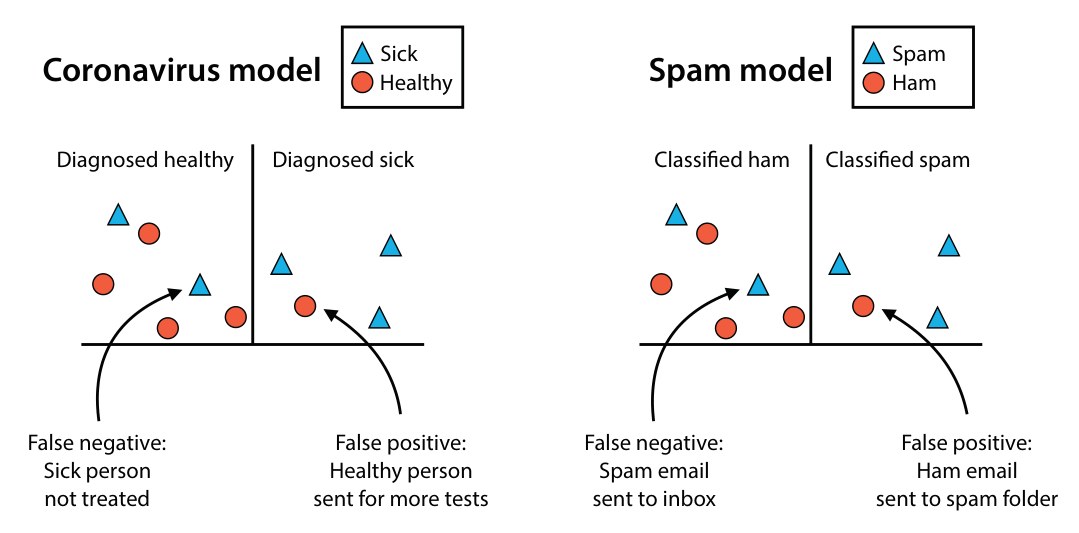

Note na imagem que, para ambas as bases, temos:

- 3 verdadeiros positivos
- 4 verdadeiros negativos
- 1 falso positivo
- 2 falsos negativos

Logo, a acurácia de ambos os modelos da figura é 7/10 = 70%. Para calcular a sensibilidade e a especificidade, usamos as fórmulas:

- especificidade = TN/(TN + FP) = 4/(4 + 1) = 0.8 = 80%
- sensibilidade = TP/(TP + FN) = 3/(3 + 2) = 0.6 = 60%

### Construindo a curva ROC

A primeira e única suposição que precisamos fazer sobre o nosso modelo é que ele retorna a predição como um valor contínuo, ou seja, como uma probabilidade. Isso é verdade em modelos como classificadores logísticos, onde a predição não é apenas uma classe, como positivo/negativo, mas um valor entre 0 e 1, como 0,7. O que normalmente fazemos com esse valor é escolher um limiar, como 0,5, e classificar cada ponto que recebe uma predição maior ou igual ao limiar como positivo e todos os outros pontos como negativos. No entanto, esse limiar pode ser qualquer valor — não precisa ser 0,5. Nosso procedimento consiste em variar esse limiar de 0 até 1 e registrar a sensibilidade e especificidade do modelo em cada valor de limiar.  

Vamos ver um exemplo. Calculamos a sensibilidade e a especificidade para três limiares diferentes: 0,2, 0,5 e 0,8. Na figura abaixo, podemos ver quantos pontos estão à esquerda e à direita da linha para cada um desses limiares. Lembre-se de que a sensibilidade é a razão entre os verdadeiros positivos e todos os positivos, e a especificidade é a razão entre os verdadeiros negativos e todos os negativos. Além disso, lembre-se de que, para cada um desses casos, há cinco positivos totais e cinco negativos totais.

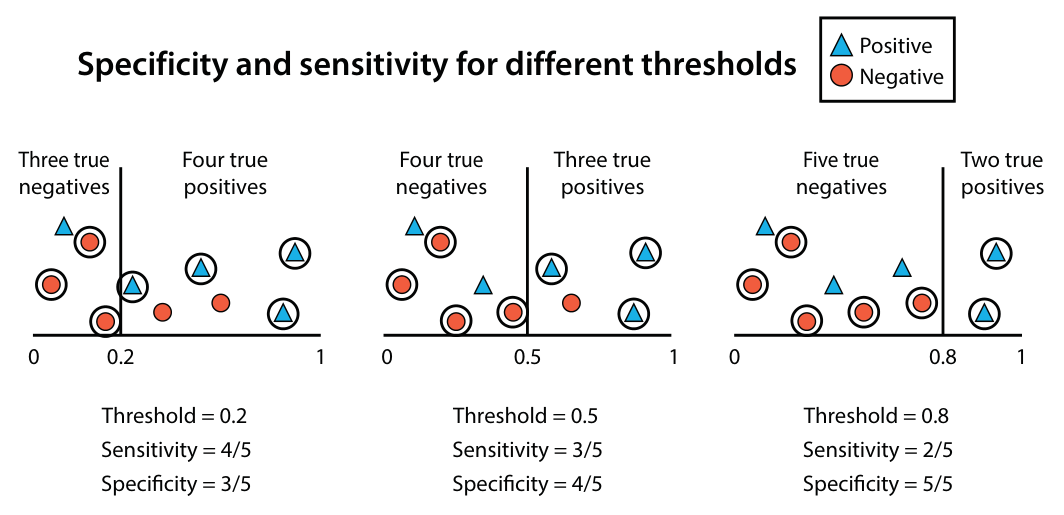

Note que um limiar baixo leva a muitas predições positivas. Portanto, teremos poucos falsos negativos, o que implica uma alta pontuação de sensibilidade, e muitos falsos positivos, o que implica uma baixa pontuação de especificidade. Da mesma forma, um limiar alto implica uma baixa pontuação de sensibilidade e uma alta pontuação de especificidade. À medida que movemos o limiar de baixo para alto, a sensibilidade diminui e a especificidade aumenta. 

Construindo uma tabela para cada limiar, obtemos:

$$
\begin{array}{|c|c|c|c|c|c|}
\hline
\text{Etapa} & \text{TP} & \text{Sensibilidade (TPR)} & \text{TN} & \text{Especificidade} & \text{FPR} \\
\hline
0 & 5 & 1 & 0 & 0 & 1 \\
1 & 5 & 1 & 1 & 0.2 & 0.8 \\
2 & 4 & 0.8 & 1 & 0.2 & 0.8 \\
3 & 4 & 0.8 & 2 & 0.4 & 0.6 \\
4 & 4 & 0.8 & 3 & 0.6 & 0.4 \\
5 & 3 & 0.6 & 3 & 0.6 & 0.4 \\
6 & 3 & 0.6 & 4 & 0.8 & 0.2 \\
7 & 2 & 0.4 & 4 & 0.8 & 0.2 \\
8 & 2 & 0.4 & 5 & 1 & 0 \\
9 & 1 & 0.2 & 5 & 1 & 0 \\
10& 0 & 0   & 5 & 1 & 0 \\
\hline
\end{array}
$$


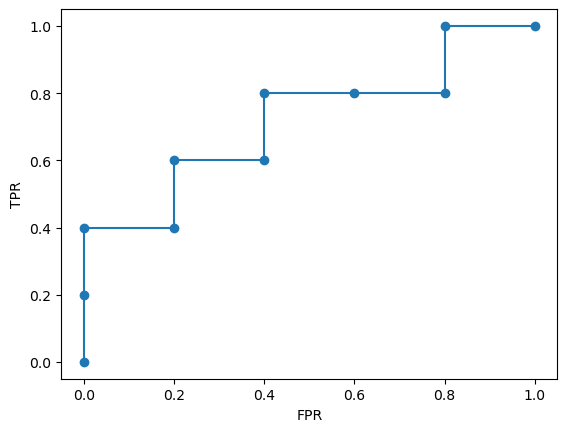

In [10]:
import matplotlib.pyplot as plt

tpr = [1, 1, 0.8, 0.8, 0.8, 0.6, 0.6, 0.4, 0.4, 0.2, 0]
fpr = [1, 0.8, 0.8, 0.6, 0.4, 0.4, 0.2, 0.2, 0, 0, 0]

plt.plot(fpr, tpr, marker='o')
plt.xlabel('FPR')
plt.ylabel('TPR')

plt.show()

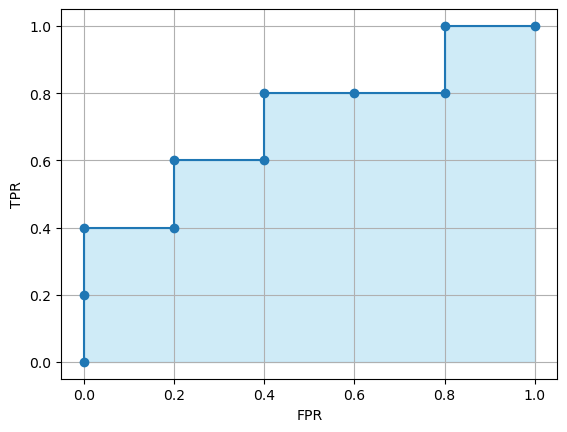

In [11]:
plt.fill_between(fpr, tpr, color='skyblue', alpha=0.4)
plt.plot(fpr, tpr, marker='o')
plt.xlabel('FPR')
plt.ylabel('TPR')

plt.grid()

plt.show()

Pode-se calcular a área sob a curva ROC (AUROC) para avaliar a qualidade do modelo. A AUROC é uma métrica que varia de 0 a 1, onde 0 indica um modelo ruim e 1 indica um modelo perfeito. A AUROC está relacionada à probabilidade de que o modelo classifique um exemplo positivo aleatório mais alto do que um exemplo negativo aleatório. Quanto maior a AUROC, melhor o modelo.

In [12]:
area = 18 / 25
area

0.72

![roc](https://upload.wikimedia.org/wikipedia/commons/thumb/3/3d/Curva_ROC.svg/640px-Curva_ROC.svg.png)

Na animação abaixo, vemos o comportamento de um modelo. Veja como a busca por mais verdadeiros positivos aumenta a taxa de falsos positivos e como a busca por diminuir falsos positivos leva à diminuição de verdadeiros positivos.

![roc gif](https://raw.githubusercontent.com/dariyasydykova/open_projects/master/ROC_animation/animations/cutoff.gif)

O formato da curva ROC muda de acordo com a capacidade que o modelo tem de classificar corretamente cada classe. A animação a seguir começa com as distribuições de cada classe sobrepostas, ou seja, o modelo não consegue distinguir as classes. Nessa situação AUC = 0.5, equivalente à um classificador aleatório (“um chute”). À medida que o modelo consegue separar mais as classes, AUC aumenta até a classificação perfeita, AUC = 1, onde a curva forma um ângulo reto.

![roc gif 2](https://raw.githubusercontent.com/dariyasydykova/open_projects/master/ROC_animation/animations/ROC.gif)

A AUROC é uma métrica bastante utilizada, especialmente com a finalidade de selecionar modelos que maximizem a área. No entanto, trabalhos na literatura demonstram que há uma métrica melhor para datasets desbalanceados.

## Precision-Recall Curve

A curva Precision-Recall é uma representação gráfica da precisão versus o recall para um sistema classificador binário à medida que o limiar de discriminação é variado. A curva Precision-Recall é criada plotando a precisão contra o recall em vários valores de limiar.

Já vimos as definições de precisão e de recall e como há um trade-off na busca por melhorar um ou outro. Isto também pode ser representado graficamente gerando uma curva e calculando a área sob esta curva. É a AUPRC (area under precision-recall curve).

Construindo uma tabela para cada limiar, obtemos:

$$
\begin{array}{|c|c|c|c|c|}
\hline
\text{Etapa} & \text{TP} & \text{TN} & \text{Precisão} & \text{Recall} \\
\hline
0 & 5 & 0 & 0.5  & 1 \\
1 & 5 & 1 & 0.56 & 1 \\
2 & 4 & 1 & 0.5  & 0.8 \\
3 & 4 & 2 & 0.57 & 0.8 \\
4 & 4 & 3 & 0.67 & 0.8 \\
5 & 3 & 3 & 0.6  & 0.6 \\
6 & 3 & 4 & 0.75 & 0.6 \\
7 & 2 & 4 & 0.66 & 0.4 \\
8 & 2 & 5 & 1    & 0.4 \\
9 & 1 & 5 & 1    & 0.2 \\
10& 0 & 5 & 1    & 0 \\
\hline
\end{array}
$$


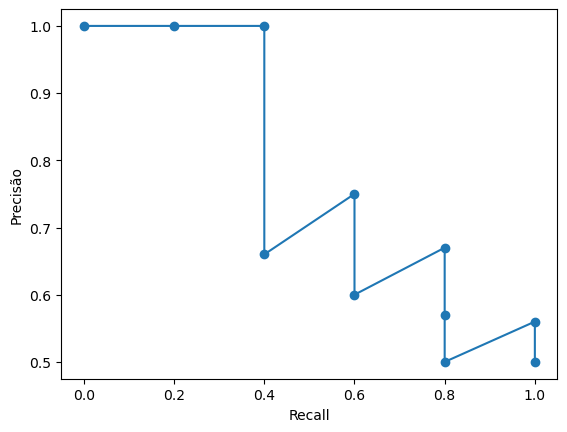

In [13]:
precisao = [0.5, 0.56, 0.5, 0.57, 0.67, 0.6, 0.75, 0.66, 1, 1, 1]
recall = [1, 1, 0.8, 0.8, 0.8, 0.6, 0.6, 0.4, 0.4, 0.2, 0]

plt.plot(recall, precisao, marker='o')
plt.xlabel('Recall')
plt.ylabel('Precisão')

plt.show()

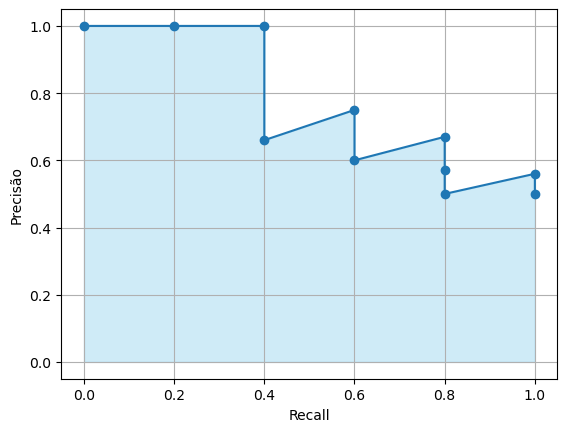

In [14]:
plt.fill_between(recall, precisao, color='skyblue', alpha=0.4)
plt.plot(recall, precisao, marker='o')
plt.xlabel('Recall')
plt.ylabel('Precisão')

plt.grid()

plt.show()

Vejamos como a AUROC e a AUPRC se comportam com a mudança na capacidade de um modelo de identificar bem duas classes na animação a seguir:

![comparacao](https://raw.githubusercontent.com/dariyasydykova/open_projects/master/ROC_animation/animations/PR.gif)

Veja que as duas curvas respondem significativamente a mudanças na capacidade de classificação.

Agora, observe as animações a seguir:

![comp desbalanceada](https://raw.githubusercontent.com/dariyasydykova/open_projects/master/ROC_animation/animations/imbalance.gif)

![comp desbalanceada 2](https://raw.githubusercontent.com/dariyasydykova/open_projects/master/ROC_animation/animations/imbalance2.gif)

Vemos nas duas animações o efeito de um grande desbalanceamento entre as classes. Veja que a AUROC permanece quase inalterada, pois o formato da curva ROC quase não se altera. Já o formato da PRC muda bastante e, consequentemente, a AUPRC.

## Resumo

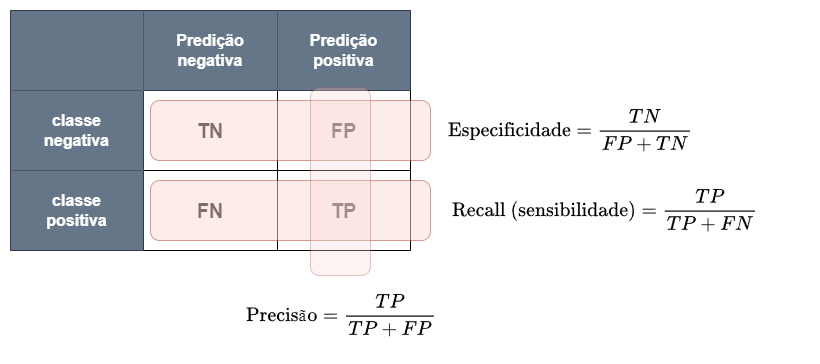

Base médica:  

• Recall e sensibilidade: entre as pessoas doentes (positivos), quantas foram corretamente diagnosticadas como doentes?  
• Precisão: entre as pessoas diagnosticadas como doentes, quantas estavam realmente doentes?  
• Especificidade: entre as pessoas saudáveis (negativos), quantas foram corretamente diagnosticadas como saudáveis?

Base de e-mail:  

• Recall e sensibilidade: entre os e-mails de spam (positivos), quantos foram corretamente excluídos?  
• Precisão: entre os e-mails excluídos, quantos eram realmente spam?  
• Especificidade: entre os e-mails ham (negativos), quantos foram corretamente enviados para a caixa de entrada?